#### Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|     Evina Fitriyani         | 5054251013       |

#### Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


#### 1. Persiapan Dataset & Eksplorasi Awal

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [23]:
# Membaca dataset
df = pd.read_csv('WineQT.csv')

# Menampilkan 5 data pertama
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [24]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [25]:
# Menampilkan statistik deskriptif
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [26]:
print("Jumlah missing value pada setiap kolom:")
print(df.isnull().sum())

Jumlah missing value pada setiap kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [27]:
# Kolom Id hanya merupakan identitas data sehingga tidak digunakan sebagai fitur
df = df.drop('Id', axis=1)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


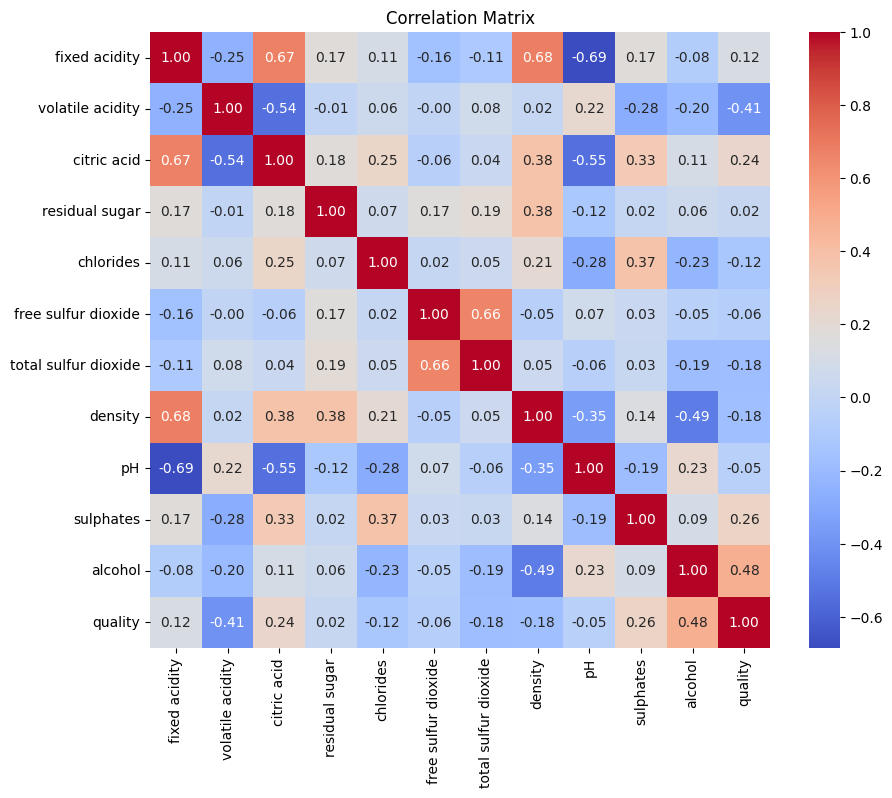

In [28]:
# Menampilkan matriks korelasi antar variabel
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [29]:
print("Jumlah data pada setiap kelas quality:")
print(df['quality'].value_counts().sort_index())

Jumlah data pada setiap kelas quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


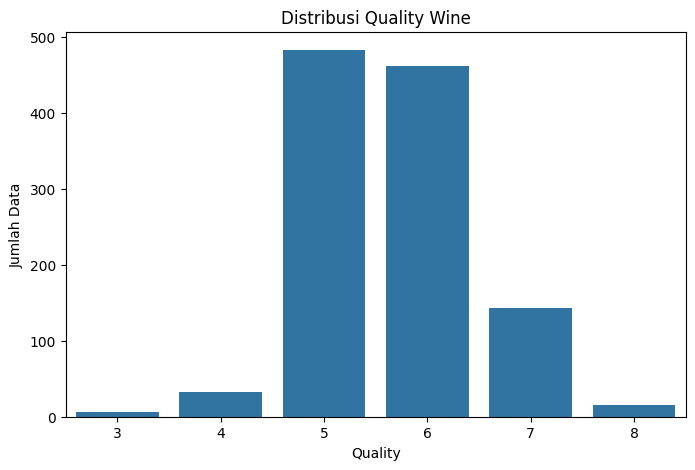

In [30]:
# Visualisasi distribusi quality

plt.figure(figsize=(8, 5))

sns.countplot(
    x='quality',
    data=df
)

plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

##### Berdasarkan distribusi label, jumlah data pada setiap kelas quality tidak sama. Kelas quality 5 dan 6 memiliki jumlah data yang lebih banyak dibandingkan kelas lainnya. Hal ini menunjukkan bahwa dataset memiliki distribusi kelas yang tidak seimbang.

##### Exploratory Data Analysis (EDA) Tambahan

EDA tambahan dilakukan untuk melihat distribusi fitur numerik dan hubungan antara kadar alkohol dengan kualitas wine.

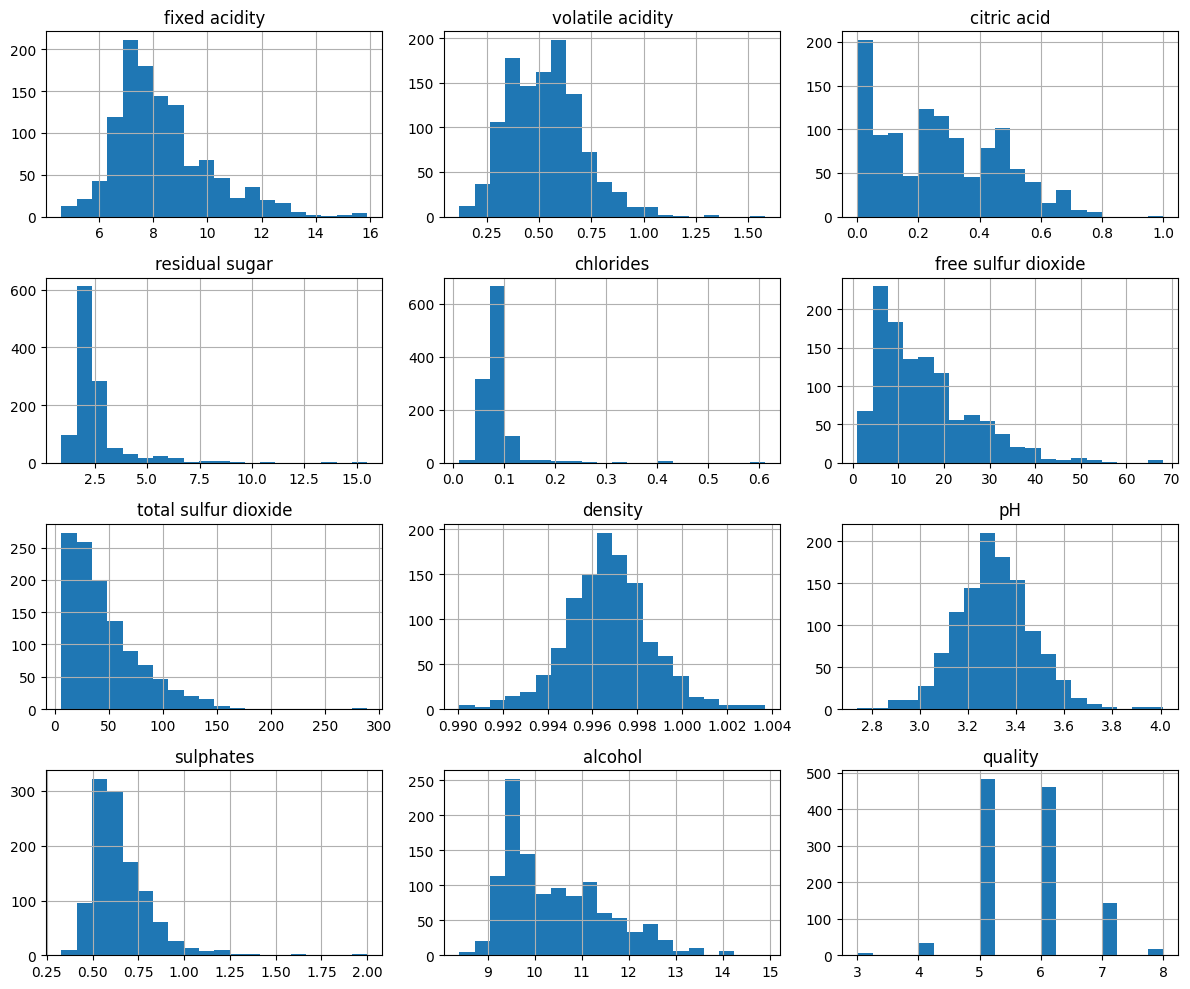

In [31]:
# Melihat distribusi setiap fitur numerik

df.hist(
    figsize=(12, 10),
    bins=20
)

plt.tight_layout()
plt.show()

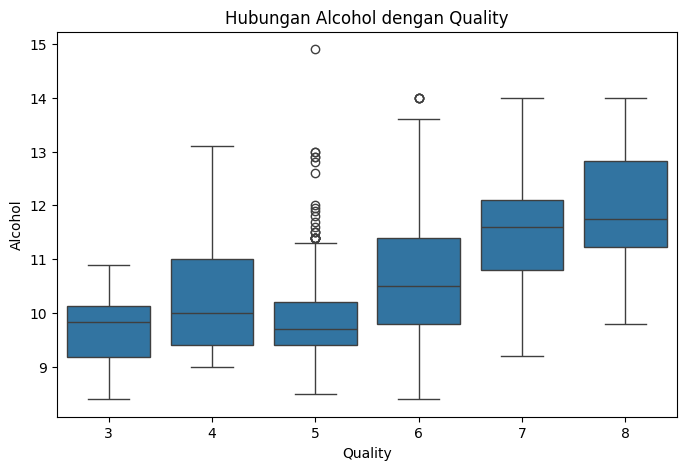

In [32]:
# Melihat hubungan kadar alkohol dengan quality

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='quality',
    y='alcohol',
    data=df
)

plt.title('Hubungan Alcohol dengan Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

##### Dari boxplot dapat dilihat bahwa distribusi kadar alkohol berbeda pada beberapa kelas quality. Secara umum, kadar alkohol pada wine dengan quality yang lebih tinggi cenderung lebih tinggi, meskipun masih terdapat tumpang tindih antar kelas.

### 2. Preprocessing




##### Pada tahap preprocessing dilakukan pemeriksaan missing value dan data duplikat. Selain itu, dilakukan pemeriksaan outlier sebagai eksperimen tambahan. Selanjutnya data dipisahkan menjadi fitur dan label, kemudian dibagi menjadi data training dan testing. Standardisasi dilakukan setelah pembagian data untuk menghindari data leakage.

In [33]:
print("Total missing value:", df.isnull().sum().sum())

Total missing value: 0


##### Hasil pengecekan menunjukkan jumlah missing value pada dataset. Jika tidak terdapat missing value, maka tidak diperlukan proses imputasi atau penghapusan data berdasarkan nilai yang hilang.

In [34]:
# Mengecek jumlah data duplikat

print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 125


In [35]:
# Menghapus data duplikat

df = df.drop_duplicates()

print("Ukuran dataset setelah menghapus duplikat:", df.shape)

Ukuran dataset setelah menghapus duplikat: (1018, 12)


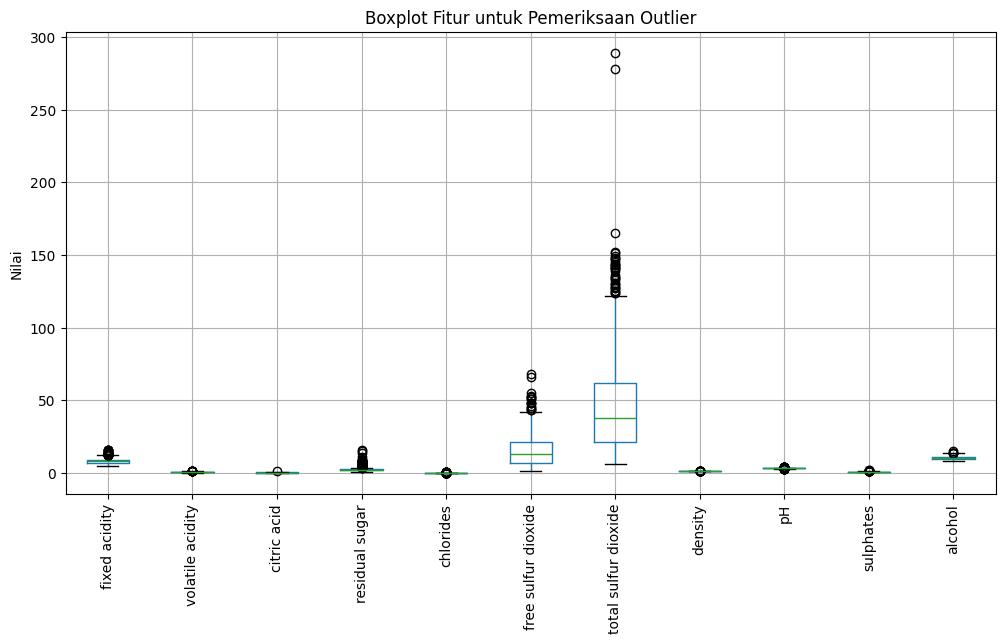

In [36]:
plt.figure(figsize=(12, 6))

df.drop('quality', axis=1).boxplot(rot=90)

plt.title('Boxplot Fitur untuk Pemeriksaan Outlier')
plt.ylabel('Nilai')

plt.show()

##### Berdasarkan boxplot, terdapat beberapa nilai yang berada di luar rentang umum pada beberapa fitur. Outlier tidak langsung dihapus karena pada dataset wine nilai tersebut masih dapat merepresentasikan karakteristik tertentu dari wine. Oleh karena itu, penghapusan outlier digunakan sebagai eksperimen tambahan untuk melihat pengaruhnya terhadap performa KNN.

In [37]:
features = df.drop('quality', axis=1)

Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)

IQR = Q3 - Q1

mask = ~(
    (features < (Q1 - 1.5 * IQR)) |
    (features > (Q3 + 1.5 * IQR))
).any(axis=1)

df_no_outlier = df[mask]

print("Ukuran data asli:", df.shape)
print("Ukuran data tanpa outlier:", df_no_outlier.shape)

Ukuran data asli: (1018, 12)
Ukuran data tanpa outlier: (756, 12)


In [38]:
X = df.drop('quality', axis=1)
y = df['quality']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (814, 11)
Data testing : (204, 11)


##### Dataset dibagi menjadi 80% data training dan 20% data testing. Parameter stratify digunakan agar proporsi kelas quality pada data training dan testing tetap relatif terjaga.

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai.")

Scaling selesai.


##### StandardScaler digunakan agar setiap fitur memiliki skala yang lebih sebanding. Scaling dilakukan setelah pembagian data untuk menghindari data leakage.

### 3. Eksperimen Model KNN




##### Pada tahap ini digunakan algoritma K-Nearest Neighbors (KNN) dengan beberapa nilai k, yaitu 3, 5, dan 7. Dua metric jarak yang digunakan adalah Euclidean dan Manhattan.

##### Setiap kombinasi parameter diuji menggunakan data training dan testing untuk membandingkan performanya.

In [41]:
k_list = [3, 5, 7]
metric_list = ['euclidean', 'manhattan']

hasil = []

for metric in metric_list:
    for k in k_list:

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train_scaled, y_train)

        pred_train = knn.predict(X_train_scaled)
        pred_test = knn.predict(X_test_scaled)

        acc_train = accuracy_score(y_train, pred_train)
        acc_test = accuracy_score(y_test, pred_test)

        hasil.append([
            metric,
            k,
            acc_train,
            acc_test
        ])

df_hasil = pd.DataFrame(
    hasil,
    columns=[
        'Metric',
        'k',
        'Akurasi Train',
        'Akurasi Test'
    ]
)

df_hasil

,Metric,k,Akurasi Train,Akurasi Test
0,euclidean,3,0.734644,0.509804
1,euclidean,5,0.678133,0.558824
2,euclidean,7,0.654791,0.568627
3,manhattan,3,0.729730,0.470588
4,manhattan,5,0.687961,0.480392
5,manhattan,7,0.664619,0.553922


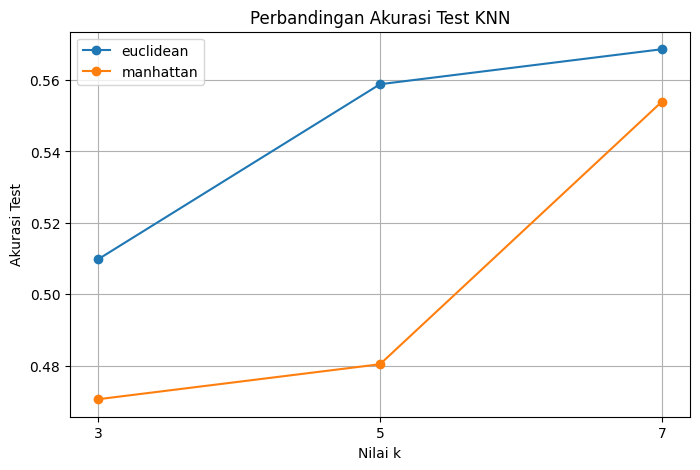

In [42]:
plt.figure(figsize=(8, 5))

for metric in metric_list:

    subset = df_hasil[
        df_hasil['Metric'] == metric
    ]

    plt.plot(
        subset['k'],
        subset['Akurasi Test'],
        marker='o',
        label=metric
    )

plt.title('Perbandingan Akurasi Test KNN')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi Test')

plt.xticks(k_list)
plt.legend()
plt.grid()

plt.show()

In [43]:
knn_noscale = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn_noscale.fit(
    X_train,
    y_train
)

pred_noscale = knn_noscale.predict(X_test)

accuracy_noscale = accuracy_score(
    y_test,
    pred_noscale
)

print(
    "Akurasi tanpa scaling:",
    round(accuracy_noscale, 4)
)

Akurasi tanpa scaling: 0.4706


In [44]:
hasil_scaled = df_hasil[
    (df_hasil['Metric'] == 'euclidean') &
    (df_hasil['k'] == 5)
]

print("Akurasi dengan scaling:")
print(round(hasil_scaled['Akurasi Test'].iloc[0], 4))

print("Akurasi tanpa scaling:")
print(round(accuracy_noscale, 4))

Akurasi dengan scaling:
0.5588
Akurasi tanpa scaling:
0.4706


In [45]:
X2 = df_no_outlier.drop('quality', axis=1)
y2 = df_no_outlier['quality']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

knn2 = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn2.fit(
    X2_train_scaled,
    y2_train
)

pred2 = knn2.predict(X2_test_scaled)

accuracy_no_outlier = accuracy_score(
    y2_test,
    pred2
)

print(
    "Akurasi tanpa outlier:",
    round(accuracy_no_outlier, 4)
)

Akurasi tanpa outlier: 0.5592


### 4. Evaluasi Model


##### Model terbaik dipilih berdasarkan nilai akurasi testing tertinggi dari seluruh kombinasi k dan metric yang telah diuji.

##### Selanjutnya dilakukan evaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

In [46]:
# Mencari eksperimen dengan akurasi test tertinggi
best_row = df_hasil.loc[
    df_hasil['Akurasi Test'].idxmax()
]

print("Model terbaik:")
print(best_row)

Model terbaik:
Metric           euclidean
k                        7
Akurasi Train     0.654791
Akurasi Test      0.568627
Name: 2, dtype: object


In [47]:
# Mengambil nilai k dan metric terbaik
best_k = int(best_row['k'])
best_metric = best_row['Metric']

print("k terbaik      :", best_k)
print("Metric terbaik :", best_metric)

k terbaik      : 7
Metric terbaik : euclidean


In [48]:
# Membuat model berdasarkan hasil eksperimen terbaik

knn_best = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

# Training model terbaik

knn_best.fit(
    X_train_scaled,
    y_train
)

# Melakukan prediksi

pred_best = knn_best.predict(
    X_test_scaled
)

In [49]:
# Menghitung metrik evaluasi

accuracy = accuracy_score(
    y_test,
    pred_best
)

precision = precision_score(
    y_test,
    pred_best,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    pred_best,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    pred_best,
    average='weighted',
    zero_division=0
)

# Menampilkan hasil evaluasi

print("Hasil Evaluasi Model Terbaik")
print("-----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Hasil Evaluasi Model Terbaik
-----------------------------
Accuracy : 0.5686
Precision: 0.5516
Recall   : 0.5686
F1-Score : 0.5593


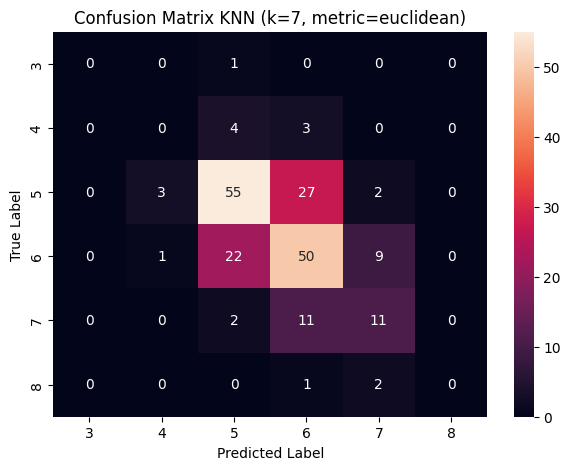

In [50]:
# Membuat confusion matrix

labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    pred_best,
    labels=labels
)

# Menampilkan confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    f'Confusion Matrix KNN '
    f'(k={best_k}, metric={best_metric})'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

### 5. Analisis

Berdasarkan hasil eksperimen, dilakukan pengujian KNN dengan nilai k = 3, 5, dan 7 serta menggunakan metrik Euclidean dan Manhattan. Hasil terbaik diperoleh pada metrik Euclidean dengan k = 7, dengan akurasi testing sebesar 56,86%.

Pada metrik Euclidean, akurasi testing meningkat dari 50,98% pada k = 3 menjadi 55,88% pada k = 5 dan 56,86% pada k = 7. Sedangkan pada metrik Manhattan, akurasi tertinggi diperoleh pada k = 7 yaitu sebesar 55,39%. Penggunaan StandardScaler juga meningkatkan akurasi dari 47,06% tanpa scaling menjadi 55,88% setelah scaling. Hal ini menunjukkan bahwa scaling cukup penting pada KNN karena algoritma ini menggunakan perhitungan jarak.

Sebagai eksperimen tambahan, dilakukan juga penghapusan outlier menggunakan metode IQR, yang mengurangi jumlah data dari 1018 menjadi 756 baris. Model KNN (k=5, Euclidean) yang dilatih pada data tanpa outlier menghasilkan akurasi testing sebesar 55,92%, hampir sama dengan akurasi pada data dengan outlier (55,88%). Ini menunjukkan bahwa penghapusan outlier pada dataset ini tidak memberikan pengaruh signifikan terhadap performa model, kemungkinan karena outlier yang terdeteksi masih merepresentasikan variasi wajar dari karakteristik kimia wine, bukan noise atau kesalahan data.

Secara keseluruhan, performa model masih belum terlalu tinggi. Salah satu penyebabnya adalah distribusi kelas quality yang tidak seimbang, terutama karena data pada quality 5 dan 6 jauh lebih banyak dibandingkan kelas lainnya.

### 6. Kesimpulan dan Saran

Berdasarkan percobaan, KNN dapat digunakan untuk mengklasifikasikan kualitas wine berdasarkan karakteristik kimianya. Hasil terbaik diperoleh pada metrik Euclidean dengan k = 7, dengan akurasi testing 56,86%, Precision 55,16%, Recall 56,86%, dan F1-Score 55,93%.

Scaling terbukti meningkatkan performa model, dari 47,06% menjadi 55,88%, karena KNN mengandalkan perhitungan jarak antar data. Sementara itu, penghapusan outlier tidak memberikan pengaruh berarti (akurasi 55,92%, hampir sama dengan yang masih mengandung outlier), sehingga bukan faktor utama yang memengaruhi performa model. Akurasi yang masih tergolong sedang ini dipengaruhi oleh ketidakseimbangan jumlah data antar kelas quality.

Sebagai saran, performa model berpotensi ditingkatkan dengan penanganan ketidakseimbangan kelas (misalnya SMOTE), pencarian nilai k yang lebih optimal lewat cross-validation, atau perbandingan dengan algoritma lain seperti Random Forest atau SVM.